In [ ]:
!pip install -q roboflow kagglehub ultralytics pyyaml

from google.colab import userdata

import os
import shutil
import yaml
from roboflow import Roboflow
import kagglehub
from google.colab import drive
from ultralytics import YOLO


# ---------------------------------------------------------------------------
# 1. Mount Google Drive
# ---------------------------------------------------------------------------
drive.mount('/content/drive')

# 1. Download dataset (Roboflow handles unzipping automatically)
rf = Roboflow('ZJW69Yn9uJoOz6qjbrLl')
fire_p = rf.workspace("samuel-adrian").project("fire-h2gkf-zjaae")
fire_v = fire_p.version(2)
fire_d = fire_v.download("yolov11")

print(f"🔥 Fire dataset location: {fire_d.location}")

# 2. Verify files are ready
print("📁 Files extracted in directory:", os.listdir(fire_d.location))

download_path = kagglehub.dataset_download("snehilsanyal/construction-site-safety-image-dataset-roboflow")
print(f"📁 Downloaded raw location: {download_path}")

target_dir = "/content/ppe-1"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(download_path, target_dir)

path_ppe = target_dir
if os.path.exists(os.path.join(target_dir, "css-data")):
    path_ppe = os.path.join(target_dir, "css-data")

import os
import yaml

# Known classes for snehilsanyal/construction-site-safety-image-dataset-roboflow
# (standard Roboflow "Construction Site Safety" PPE export, in original class-id order)
ppe_class_names = [
    "Hardhat",
    "Mask",
    "NO-Hardhat",
    "NO-Mask",
    "NO-Safety Vest",
    "Person",
    "Safety Cone",
    "Safety Vest",
    "machinery",
    "vehicle",
]

ppe_yaml_path = os.path.join(path_ppe, "data.yaml")

if not os.path.exists(ppe_yaml_path):
    ppe_yaml = {
        "path": path_ppe,
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": len(ppe_class_names),
        "names": {i: name for i, name in enumerate(ppe_class_names)},
    }
    with open(ppe_yaml_path, "w") as f:
        yaml.dump(ppe_yaml, f, default_flow_style=False)
    print(f"✅ Generated PPE data.yaml at: {ppe_yaml_path}")
else:
    print(f"ℹ️ data.yaml already exists at {ppe_yaml_path}, not overwriting.")
    with open(ppe_yaml_path, "r") as f:
        print(yaml.safe_load(f))

import os
import yaml

# Known classes for snehilsanyal/construction-site-safety-image-dataset-roboflow
# (standard Roboflow "Construction Site Safety" PPE export, in original class-id order)
ppe_class_names = [
    "Hardhat",
    "Mask",
    "NO-Hardhat",
    "NO-Mask",
    "NO-Safety Vest",
    "Person",
    "Safety Cone",
    "Safety Vest",
    "machinery",
    "vehicle",
]

ppe_yaml_path = os.path.join(path_ppe, "data.yaml")

if not os.path.exists(ppe_yaml_path):
    ppe_yaml = {
        "path": path_ppe,
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": len(ppe_class_names),
        "names": {i: name for i, name in enumerate(ppe_class_names)},
    }
    with open(ppe_yaml_path, "w") as f:
        yaml.dump(ppe_yaml, f, default_flow_style=False)
    print(f"✅ Generated PPE data.yaml at: {ppe_yaml_path}")
else:
    print(f"ℹ️ data.yaml already exists at {ppe_yaml_path}, not overwriting.")
    with open(ppe_yaml_path, "r") as f:
        print(yaml.safe_load(f))

# ---------------------------------------------------------------------------
# 4. Read each dataset's OWN data.yaml and build a name-based class mapping
#    This is the key fix: we no longer assume class order/IDs, we read the
#    actual names each dataset ships with and remap by name, not by index.
# ---------------------------------------------------------------------------
def load_names(dataset_path):
    yaml_path = os.path.join(dataset_path, "data.yaml")
    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f"No data.yaml found in {dataset_path}")
    with open(yaml_path, "r") as f:
        cfg = yaml.safe_load(f)
    names = cfg["names"]
    # names can be a list or a dict depending on how Roboflow exported it
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys(), key=int)]
    return names

ppe_names = load_names(path_ppe)
fire_names = load_names(fire_d.location)

print("PPE dataset classes (as read from its own data.yaml):", ppe_names)
print("Fire dataset classes (as read from its own data.yaml):", fire_names)

# Build the master class list: PPE classes first (in their own order),
# then any Fire classes not already present in PPE (avoids accidental dupes
# like a stray 'Person' class in the fire dataset).
master_names = list(ppe_names)
for n in fire_names:
    if n not in master_names:
        master_names.append(n)

print("✅ Master class list:", master_names)

# old_id -> new_id maps, built from names, per dataset
ppe_id_map = {old_id: master_names.index(name) for old_id, name in enumerate(ppe_names)}
fire_id_map = {old_id: master_names.index(name) for old_id, name in enumerate(fire_names)}

# Sanity check: confirm nothing unexpected leaked into the fire dataset
# (e.g. a 'Person' class), since you specifically wanted these disjoint.
unexpected_overlap = [n for n in fire_names if n in ppe_names]
if unexpected_overlap:
    print(f"⚠️ WARNING: fire dataset shares class names with PPE dataset: {unexpected_overlap}")
    print("   These will be merged into the SAME class id. Confirm this is intended.")

# ---------------------------------------------------------------------------
# 5. Merge Datasets into Master Dataset (PPE + Fire), remapping by name
# ---------------------------------------------------------------------------
master_dataset = "/content/master_dataset"
if os.path.exists(master_dataset):
    shutil.rmtree(master_dataset)

splits = ['train', 'valid', 'test']
for split in splits:
    os.makedirs(f"{master_dataset}/{split}/images", exist_ok=True)
    os.makedirs(f"{master_dataset}/{split}/labels", exist_ok=True)

datasets = [
    {"name": "ppe", "path": path_ppe, "id_map": ppe_id_map},
    {"name": "fire", "path": fire_d.location, "id_map": fire_id_map},
]

merge_stats = {split: {"images": 0, "labels": 0, "empty_labels": 0} for split in splits}

for ds in datasets:
    print(f"Merging {ds['name']}...")
    for split in splits:
        img_dir = os.path.join(ds['path'], split, 'images')
        lbl_dir = os.path.join(ds['path'], split, 'labels')

        if not os.path.exists(img_dir):
            continue

        for img_name in os.listdir(img_dir):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            # Prefix filename to prevent overwriting images across datasets
            new_img_name = f"{ds['name']}_{img_name}"
            shutil.copy(
                os.path.join(img_dir, img_name),
                os.path.join(master_dataset, split, 'images', new_img_name)
            )
            merge_stats[split]["images"] += 1

            # Remap class IDs by name-derived mapping, not a fixed offset
            lbl_name = img_name.rsplit('.', 1)[0] + '.txt'
            old_lbl_path = os.path.join(lbl_dir, lbl_name)
            new_lbl_path = os.path.join(master_dataset, split, 'labels', f"{ds['name']}_{lbl_name}")

            if os.path.exists(old_lbl_path):
                with open(old_lbl_path, 'r') as f_in, open(new_lbl_path, 'w') as f_out:
                    for line in f_in:
                        parts = line.strip().split()
                        if not parts:
                            continue
                        old_class_id = int(parts[0])
                        new_class_id = ds['id_map'][old_class_id]
                        f_out.write(f"{new_class_id} " + " ".join(parts[1:]) + "\n")
                merge_stats[split]["labels"] += 1
            else:
                # Explicit empty label file = "no objects", not "missing data"
                open(new_lbl_path, 'w').close()
                merge_stats[split]["empty_labels"] += 1

print("✅ Datasets (PPE + Fire) successfully merged!")

# ---------------------------------------------------------------------------
# 6. Sanity check: confirm image/label counts line up per split
# ---------------------------------------------------------------------------
for split in splits:
    n_img = len(os.listdir(f"{master_dataset}/{split}/images"))
    n_lbl = len(os.listdir(f"{master_dataset}/{split}/labels"))
    print(f"[{split}] images={n_img} labels={n_lbl} "
          f"(copied: img={merge_stats[split]['images']}, "
          f"non-empty_lbl={merge_stats[split]['labels']}, "
          f"empty_lbl={merge_stats[split]['empty_labels']})")
    assert n_img == n_lbl, f"Mismatch in {split}: every image needs exactly one label file"

# ---------------------------------------------------------------------------
# 7. Create Master YAML Config
# ---------------------------------------------------------------------------
master_yaml = {
    'path': master_dataset,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(master_names),
    'names': {i: name for i, name in enumerate(master_names)},
}

master_yaml_path = f"{master_dataset}/data.yaml"
with open(master_yaml_path, 'w') as f:
    yaml.dump(master_yaml, f, default_flow_style=False)

print(f"✅ Master YAML Config created at: {master_yaml_path}")
print(f"   nc={master_yaml['nc']}, names={master_yaml['names']}")

model = YOLO("yolo26m.pt")

drive_output_path = "/content/drive/MyDrive/AI_Project"

# results = model.train(
#     data=master_yaml_path,
#     epochs=100,
#     imgsz=896,
#     batch=24,
#     device=0,

#     project=drive_output_path,
#     name="ppe_fire_yolo26m",

#     lr0=0.001,
#     scale=0.7,
#     mosaic=1.0,
#     box=8.5,
# )

KeyboardInterrupt: 

In [ ]:

# 2. Path to the last checkpoint in your Google Drive save directory
checkpoint_path = "/content/drive/MyDrive/AI_Project/ppe_fire_yolo26m/weights/last.pt"

if os.path.exists(checkpoint_path):
    # 3. Load the partially trained checkpoint
    model = YOLO(checkpoint_path)

    # 4. Resume training (restores exact arguments, data yaml, and optimizer states)
    results = model.train(resume=True)
else:
    print(f"❌ Checkpoint not found at: {checkpoint_path}")

Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=8.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/master_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=896, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/AI_Project/ppe_fire_yolo26m/weights/last.pt, momentum=0.937, mos

Displaying plots from: /content/drive/MyDrive/AI_Project/ppe_fire_yolo26m

--- Results ---


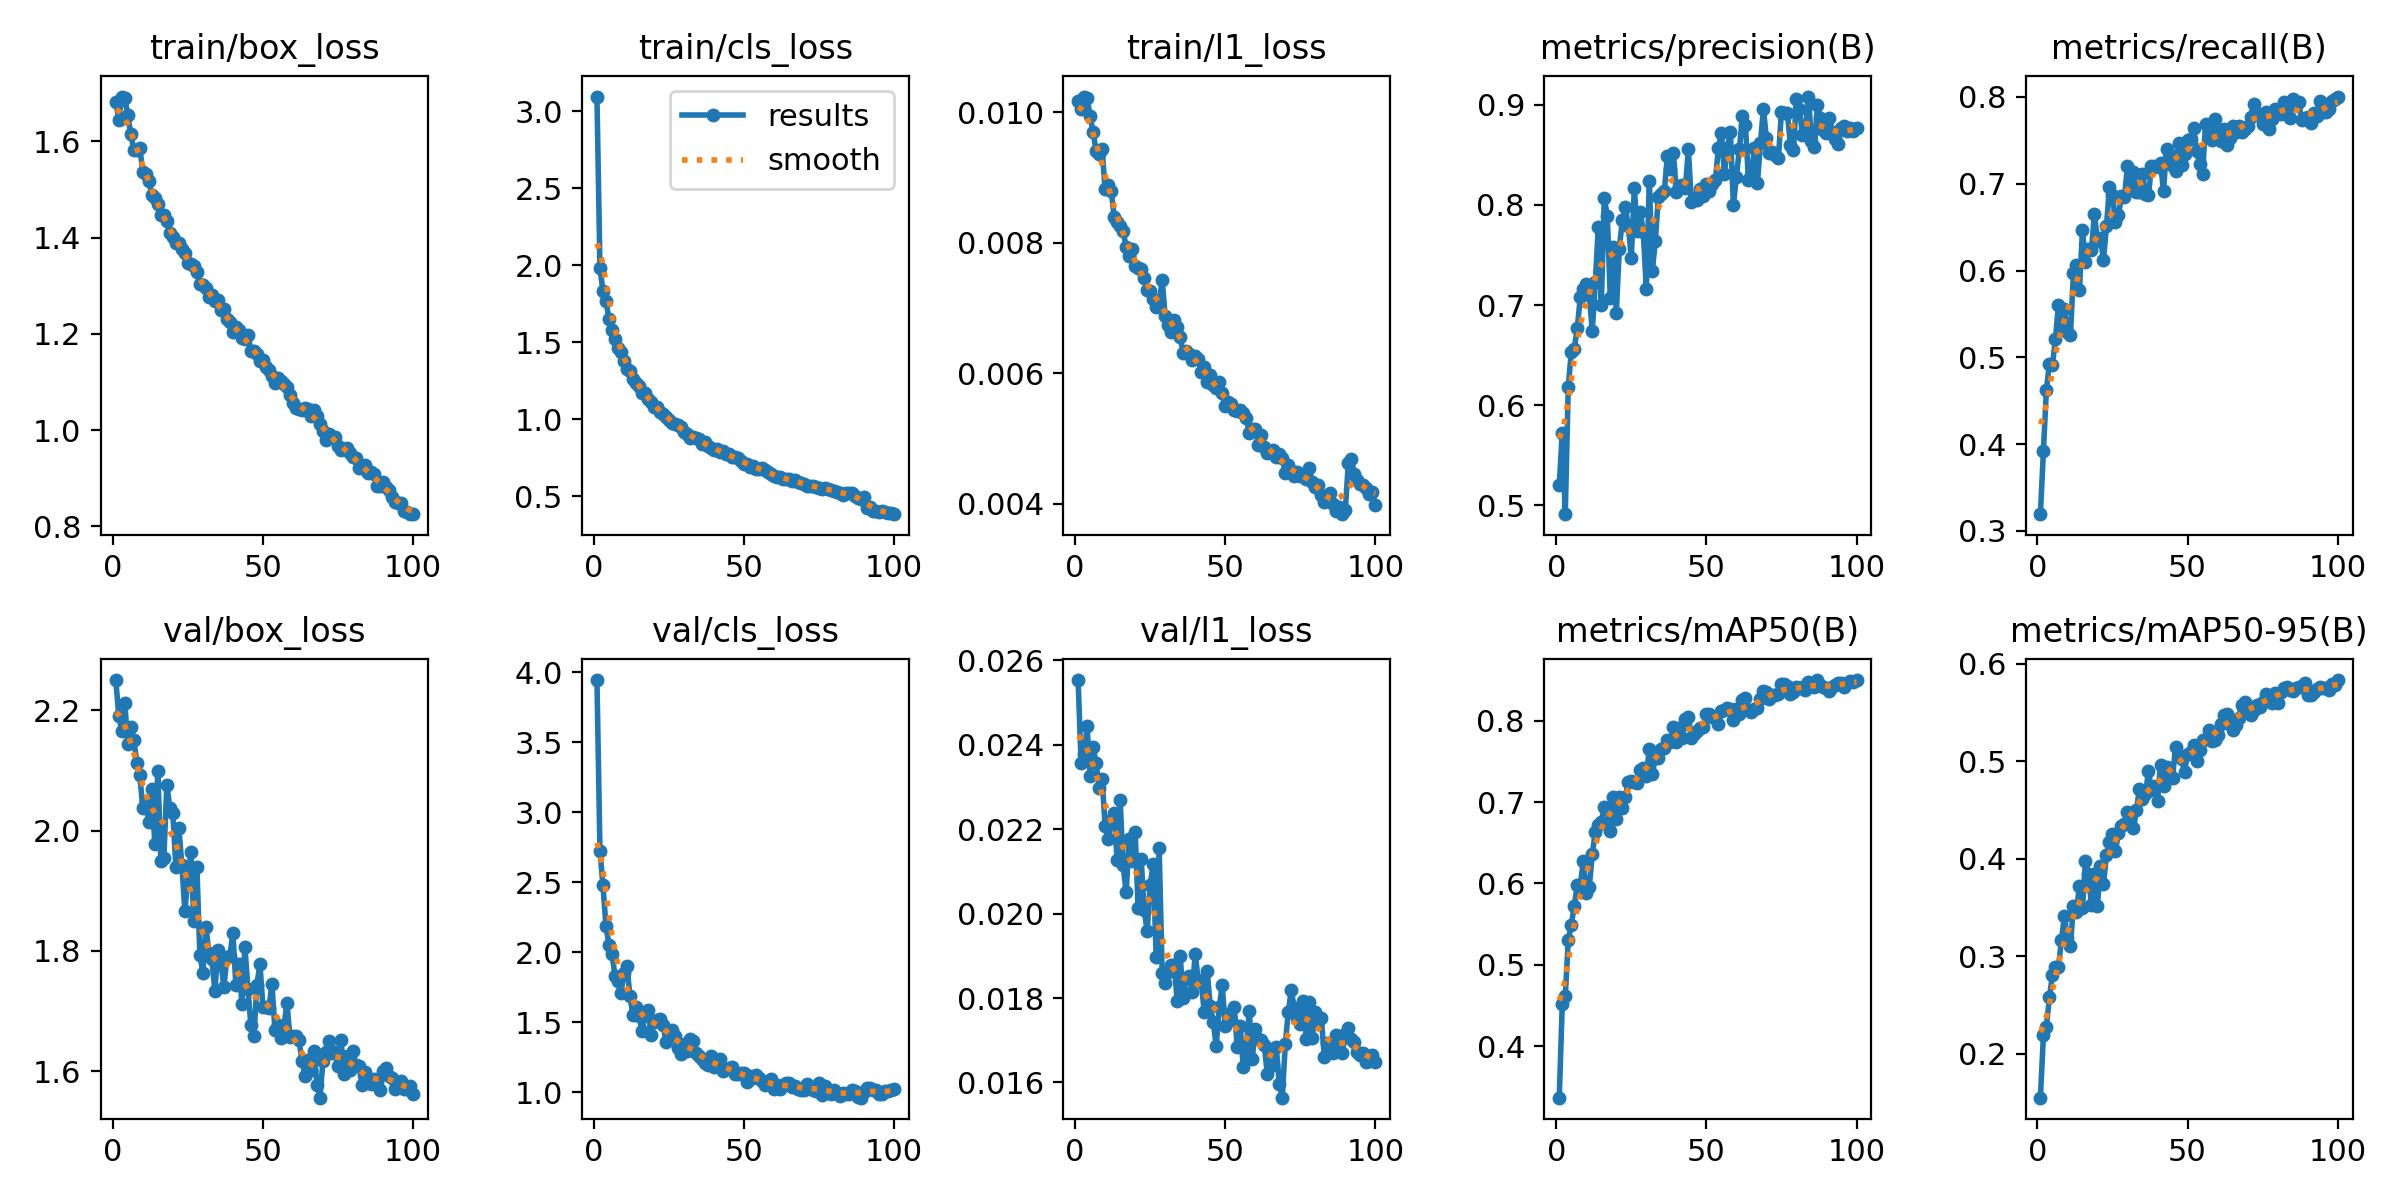


--- Confusion Matrix ---


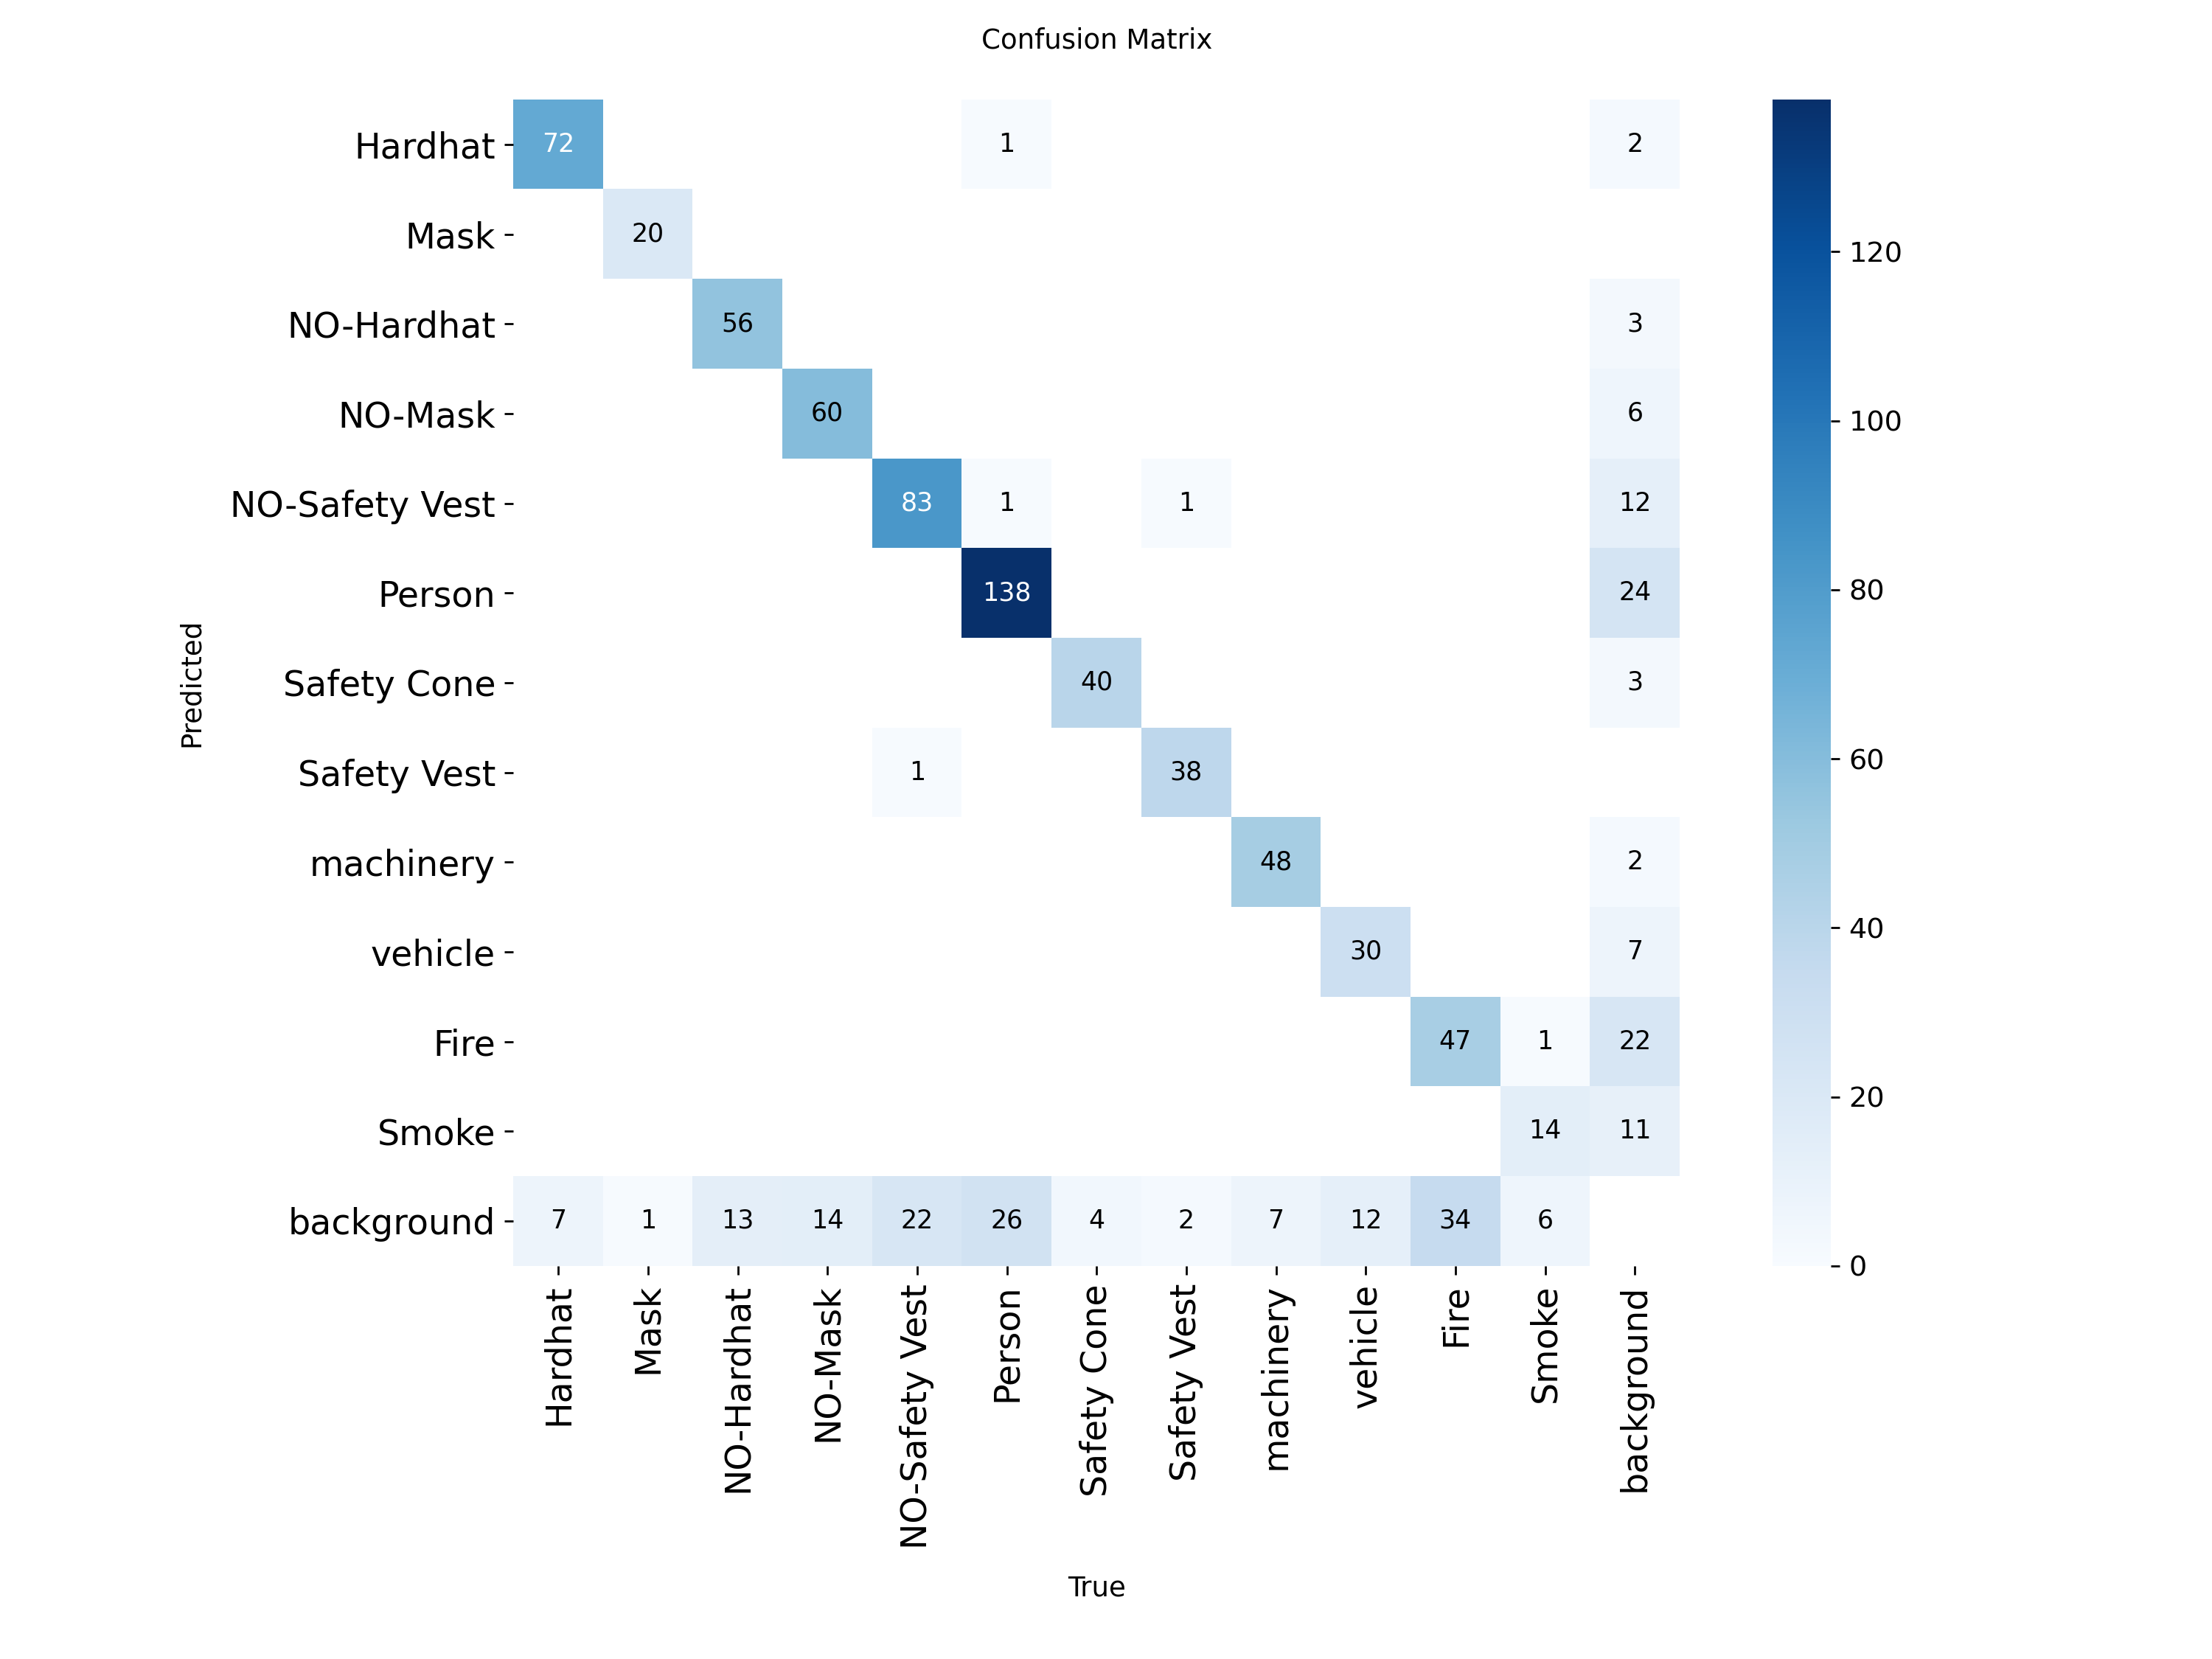


--- Confusion Matrix Normalized ---


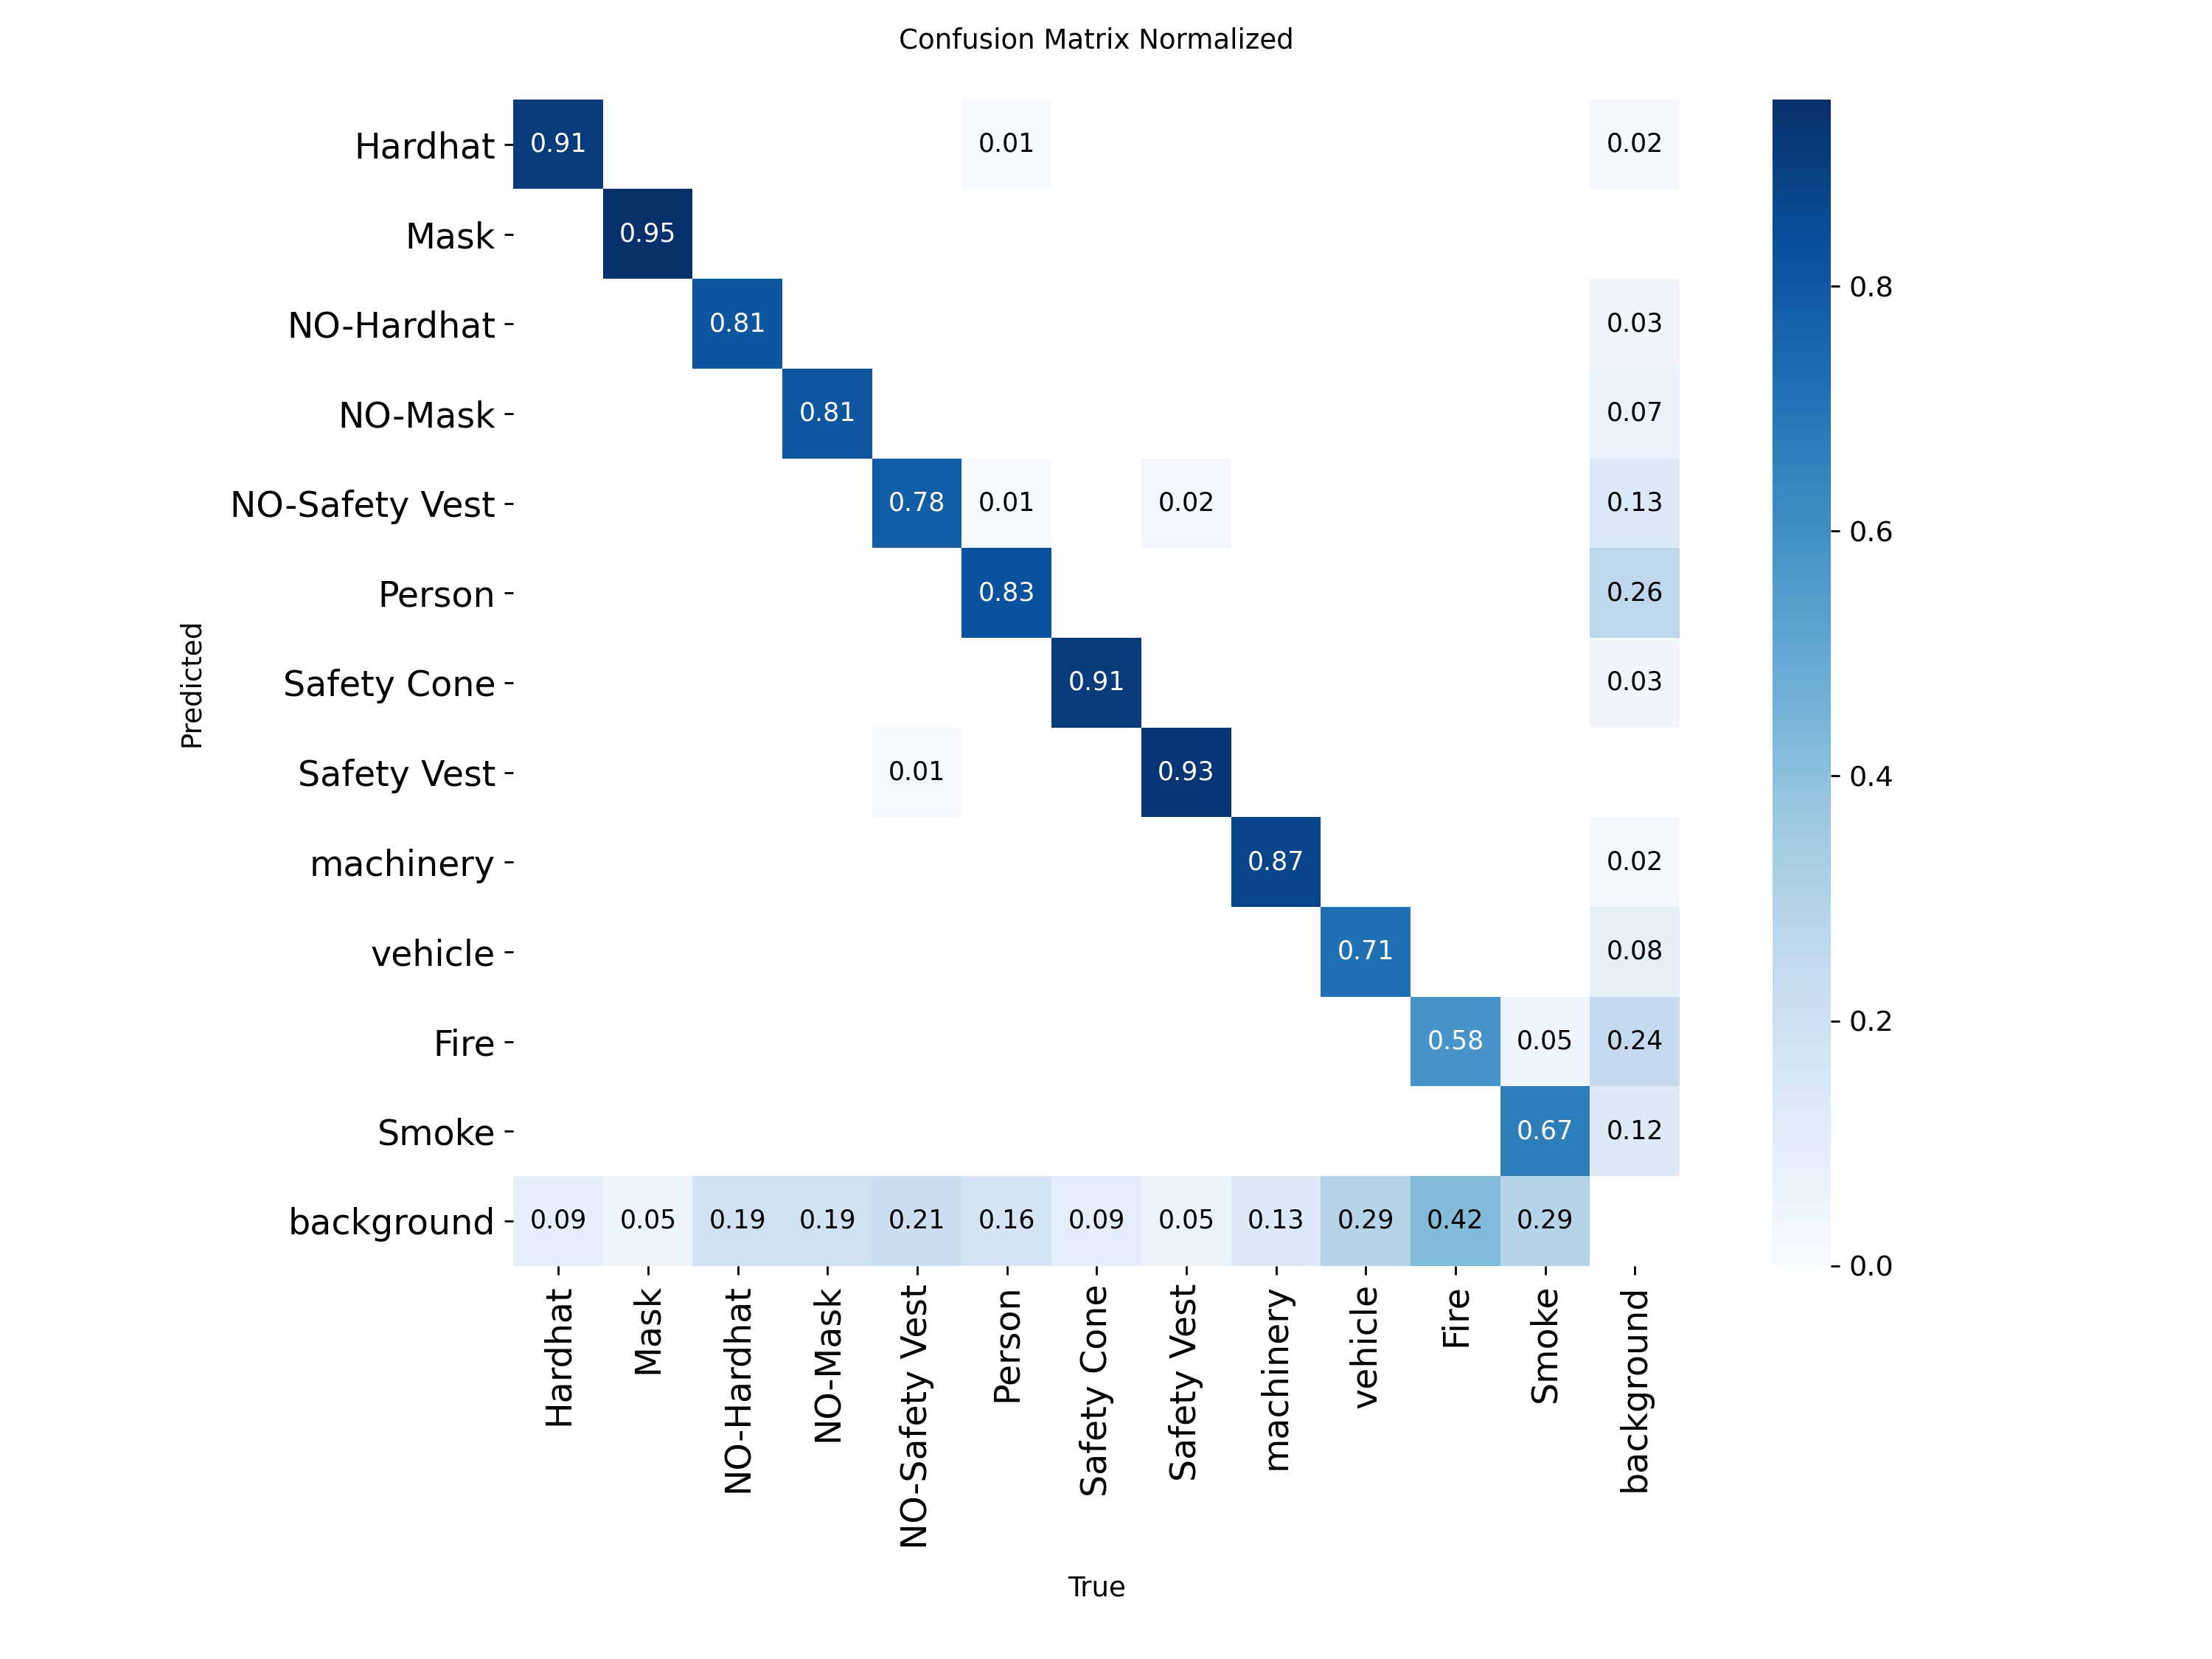

In [ ]:
from IPython.display import Image, display
import os

# Define the directory where the training results were saved
save_dir = os.path.join(drive_output_path, "ppe_fire_yolo26m")

# List of common plot files generated by Ultralytics
plot_files = [
    'results.png',
    'F1_curve.png',
    'P_curve.png',
    'R_curve.png',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png'
]

print(f"Displaying plots from: {save_dir}")

for plot_file in plot_files:
    plot_path = os.path.join(save_dir, plot_file)
    if os.path.exists(plot_path):
        print(f"\n--- {plot_file.replace('_', ' ').replace('.png', '').title()} ---")
        display(Image(filename=plot_path, width=800))
    else:
        print(f"Warning: {plot_file} not found at {plot_path}")

In [ ]:
from google.colab import files
import shutil

# Zip the master_dataset folder
shutil.make_archive('master_dataset', 'zip', '/content/master_dataset')

# Download the zip file
files.download('master_dataset.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>